In [1]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='../figures/ClonalGenesCorrelations/7.14_LabMeeting/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

In [3]:
# Load the Data

In [2]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(3394, 98) (17819, 2) shape of adata after filtering 


In [ ]:
# Select only the B cells I cultured and Activated
selector = adata.obs[adata.obs['Exp_Labels'].str.contains('Activation')].index
df = df[df.index.isin(selector)]
adata_obs = adata.obs[adata.obs.index.isin(df.index)]

In [4]:
adata_obs = adata.obs

#### MALAT1 Test Histogram

(3370, 99)
(361, 99)


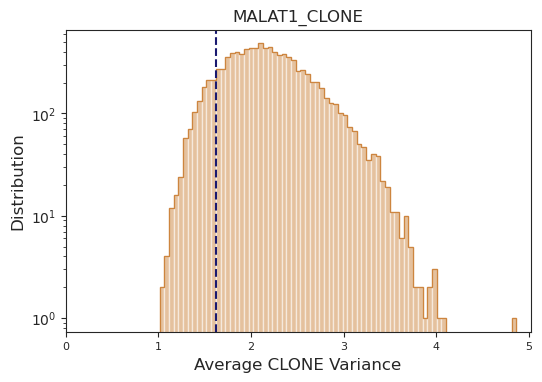

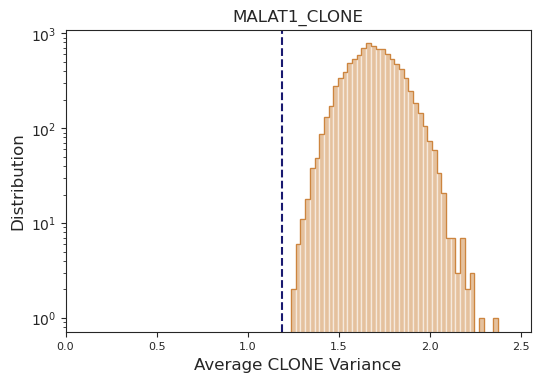

In [8]:
fig1 = cs.plotTestHist(df, adata_obs, 10000, 'MALAT1', 'CLONE', filterzeroes = False)
fig2 = cs.plotTestHist(df, adata_obs, 10000, 'MALAT1', 'CLONE', filterzeroes = True)

In [10]:
save_figure(fig1, "MALAT1_TestHist_WithZeroes", output_dir='../figures/PaperDraft1/')
save_figure(fig2, "MALAT1_TestHist_NoZeroes", output_dir='../figures/PaperDraft1/')

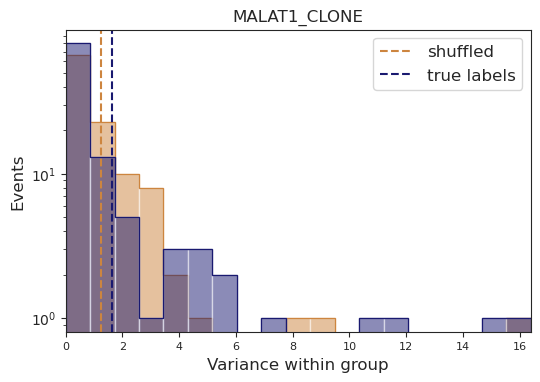

In [28]:
fig, data, data_shuffled = cs.plotEgHists(df, adata_obs, 1, 'MALAT1', 'CLONE')

In [29]:
save_figure(fig, "MALAT1_Shuffled_True_EgHist", output_dir='../figures/PaperDraft1/')

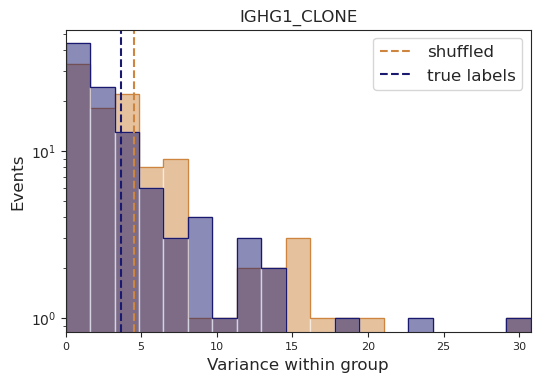

In [279]:
data, data_shuffled = cs.plotEgHists(df, adata_obs, 1, 'IGHG1', 'CLONE')

Text(0.5, 1.0, 'IGKC_Clone')

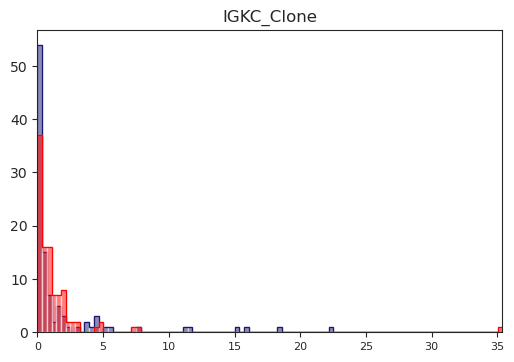

In [231]:
gene = 'IGKC'
label = 'Clone'
data = data[data > 0]

data_shuffled = data_shuffled[data_shuffled > 0]
fig, ax = plt.subplots(1,1)
xmax = data_shuffled.max() + 0.2
bins = np.linspace(0, xmax, 100)
plt.hist(data, bins = bins, color = 'midnightblue', alpha = 0.5)
plt.hist(data, bins = bins, color = 'midnightblue', histtype='step')
plt.hist(data_shuffled, bins = bins, color = 'red', alpha = 0.5)
plt.hist(data_shuffled, bins = bins, color = 'red', histtype='step')

#plt.axvline(mean_observedlabel_variance, 0, 1, c = 'red', ls = '--')
plt.yscale('linear')
plt.xscale('linear')
plt.xlim(0, xmax)
plt.title(gene + '_' + label)

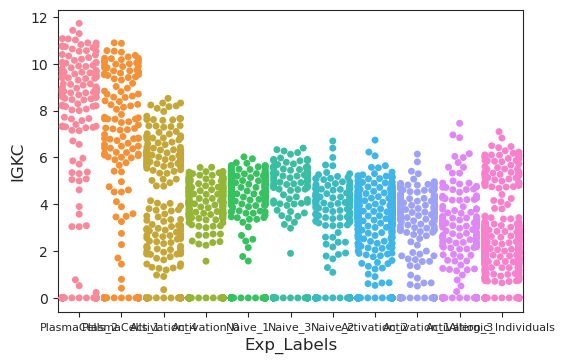

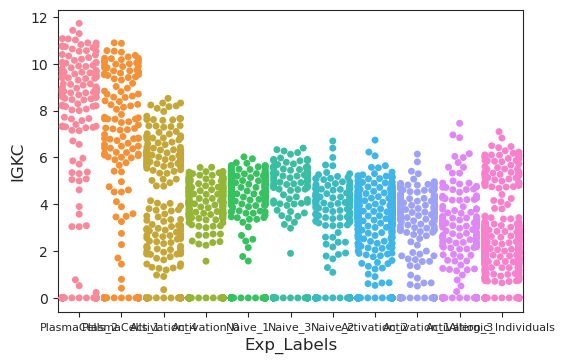

In [30]:
g = cs.plotSwarm(df, adata_obs, 'IGKC', 'Exp_Labels')
g = cs.plotSwarm(df, adata_obs, 'IGKC', 'Exp_Labels')

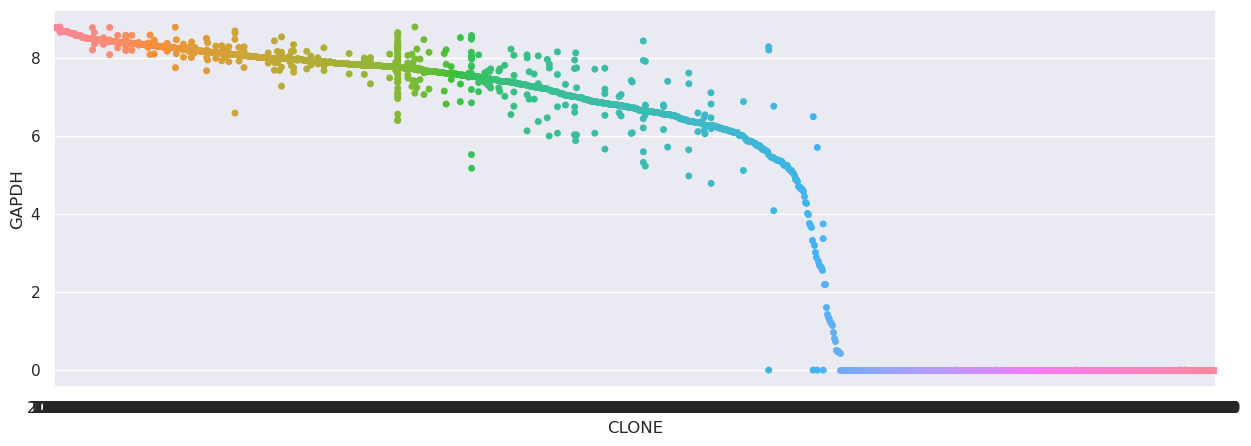

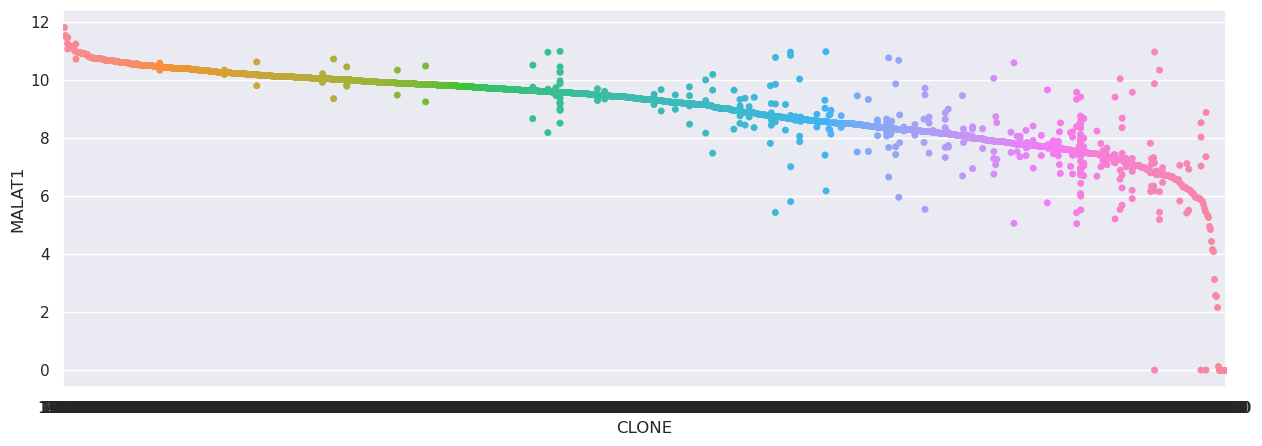

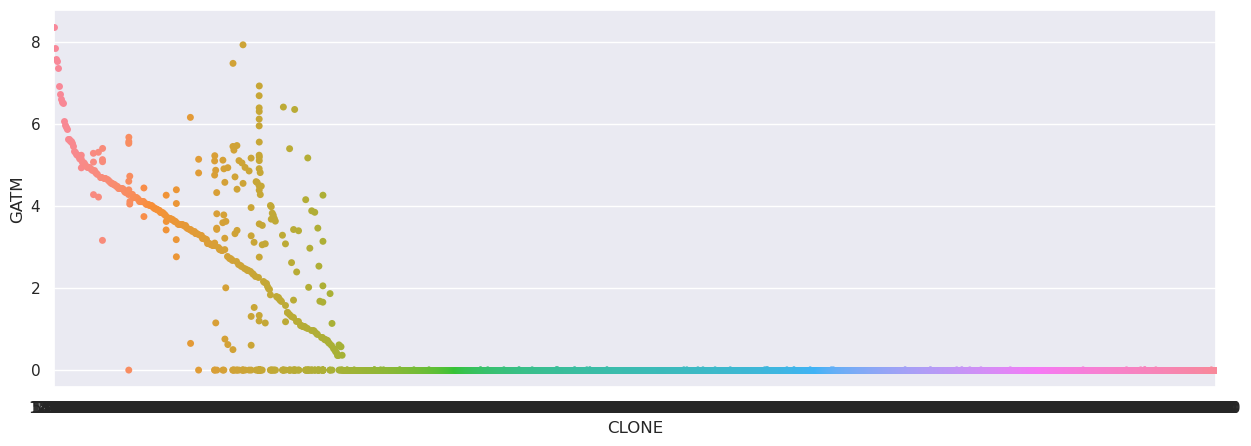

In [443]:
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'MALAT1', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'GATM', 'CLONE')


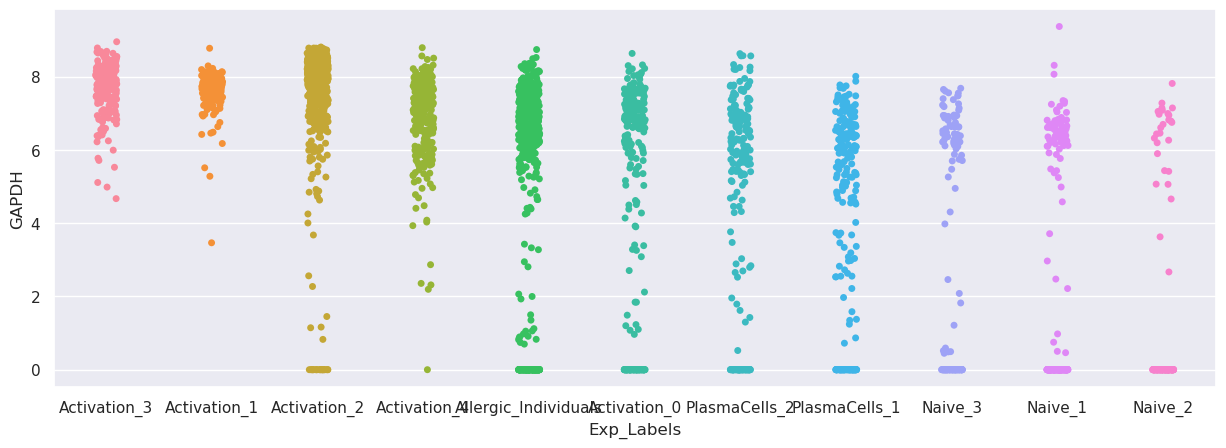

In [446]:
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'Exp_Labels')


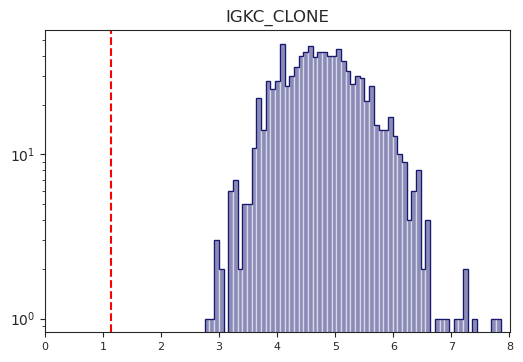

In [236]:
fig = cs.plotTestHist(df, adata.obs, 1000, 'IGKC', 'CLONE')

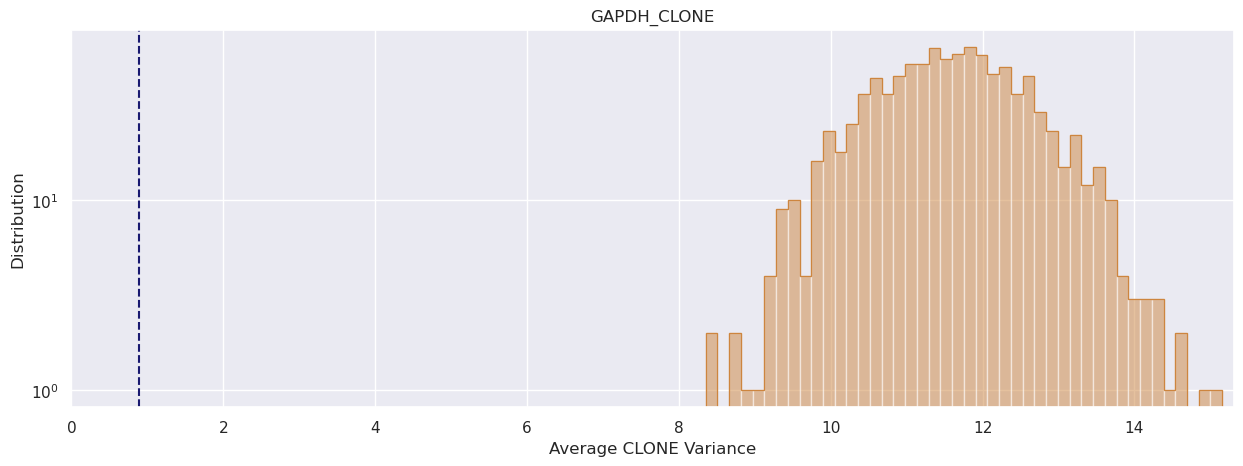

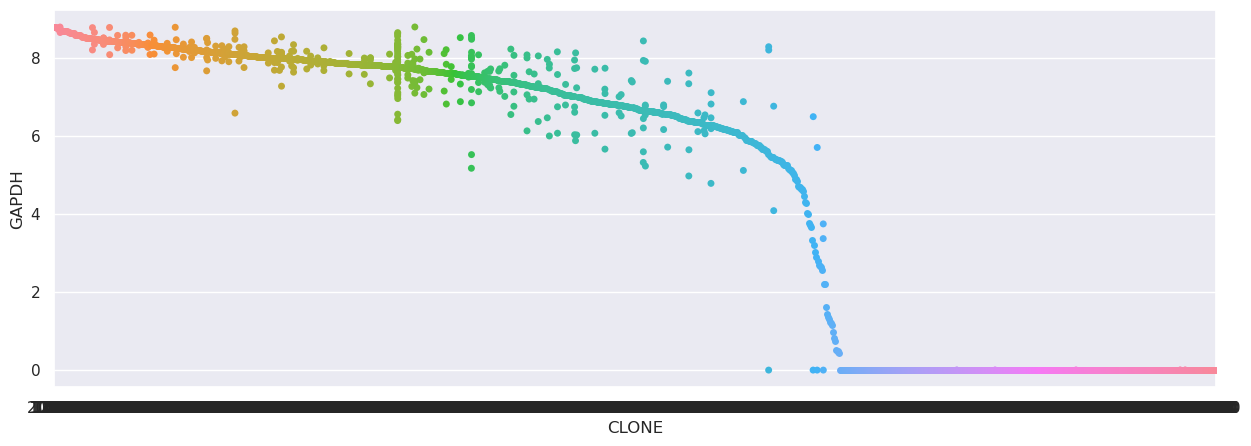

In [444]:
cs.plotTestHist(df, adata.obs, 10000, 'GAPDH', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'CLONE')

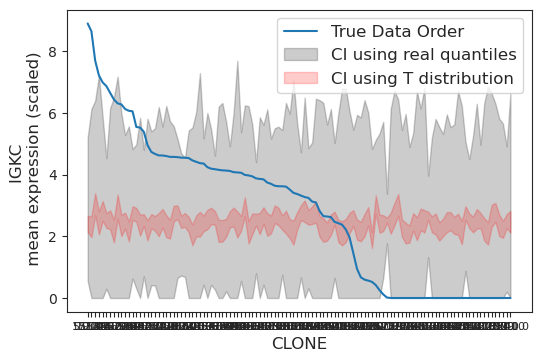

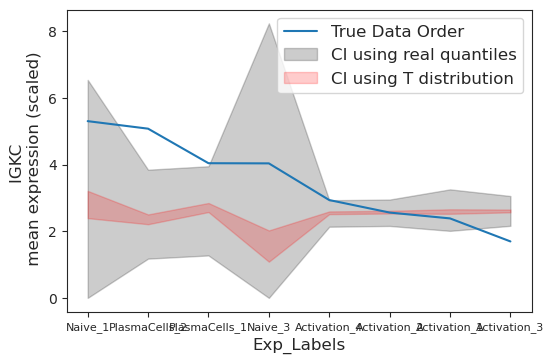

In [114]:
data = plotCI(df, adata.obs, 100, 'IGKC', 'CLONE', 0.95)
data = plotCI(df, adata.obs, 100, 'IGKC', 'Exp_Labels', 0.95)

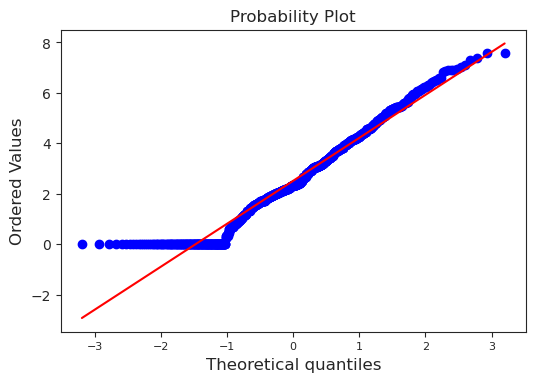

In [102]:
# 
import statsmodels
# generate t distribution
import scipy.stats as stats
import pylab
import numpy as np

oneClone = shuffledmeans.iloc[2,:][:-5].values

measurements = oneClone
#measurements = np.random.normal(loc = oneClone.mean(), scale = oneClone.std(), size = 1000)
g = stats.probplot(measurements, dist = "norm", plot=pylab)

## Division Data

In [6]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(3394, 98) (17819, 2) shape of adata after filtering 


# Cells which still have no division information even though it seems like they should
# not too worried about this because 4 of the 5 don't have bracer assemblies, suggesting I wouldn't even use them

In [7]:
# Replace None with 100 for easier numeric based filtering 
adata.obs.loc[:,'DivisionNumber'] = adata.obs.DivisionNumber.str.replace('None', '100')
# Replace max with 7, should really be 7+ but that isn't a number 
adata.obs.loc[:,'DivisionNumber'] = adata.obs.DivisionNumber.str.replace('Max', '7')
# Make Numerica
adata.obs['DivisionNumber'] = pd.to_numeric(adata.obs['DivisionNumber'])

In [8]:
adata = adata[adata.obs.Condition_Labels == 'Activation', :]

In [9]:
adata.obs

,Donor_x,Exp_Labels,Condition_Labels,SEQUENCE_ID,SEQUENCE_INPUT,FUNCTIONAL,IN_FRAME,STOP,MUTATED_INVARIANT,INDELS,...,None: PerCP-Cy5.5-A-Compensated,None: PE-Cy7-A-Compensated,None: FITC-A-Compensated,EtBr: PI-A-Compensated,Plate,CertaintyAboutPipetting,DivisionNumber,temp,n_genes,n_counts
CTY_I8,Donor_1,Activation_1,Activation,bracer_CTY_I8_TRINITY_DN0_c0_g1_i1_H Donor_1,AAGGTGTCCAGTGTGAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTT...,True,True,False,NaN,False,...,NaN,NaN,NaN,NaN,nan,nan,4,4,7439,1453394.0
MS_SISTER2_J10,Donor_1,Activation_2,Activation,bracer_MS_SISTER2_J10_TRINITY_DN2_c0_g3_i1_H D...,ATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTG...,True,True,False,NaN,False,...,NaN,NaN,NaN,NaN,nan,nan,3,3,9518,977415.0
MS_IL4_F1,Donor_1,Activation_2,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,7,Max,6437,158406.0
CTY_H21,Donor_1,Activation_1,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,3,3,3536,133583.0
MS_IL4_L6,Donor_1,Activation_2,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,4,4,8885,1456428.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IL6811_716_503,Donor_0,Activation_0,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,100,None,1224,540170.0
IL6811_710_505,Donor_0,Activation_0,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,100,None,1310,585910.0
IL6811_706_520,Donor_0,Activation_0,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,100,None,1204,427084.0
IL6811_722_517,Donor_0,Activation_0,Activation,nan,nan,nan,nan,nan,NaN,nan,...,NaN,NaN,NaN,NaN,nan,nan,100,None,1430,410846.0


In [10]:
df = df[df.index.isin(adata.obs.index)]

In [11]:
# Only Activated B Cells
selector = adata.obs.CLONE.value_counts() > 1
selector = selector[selector == True]


# Only Cells with clones?
_adata = adata[adata.obs.CLONE.isin(selector.index), :]
_df = df[df.index.isin(_adata.obs.index)]



In [ ]:
# Load the Tests
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Exp_Labels_tests.csv', index_col = 0)

In [635]:
# Create a new dataframe with the comparison as a column, the added division number, and pearson correllation
import itertools
def compareGenesbyDivision(df, adata):
    comparison = []
    clonal = []
    division_sum = []
    division_diff = []
    for cell1, cell2 in itertools.combinations(df.index, 2):
        # Clone Test Comparison
        if adata.obs.loc[cell1].CLONE == adata.obs.loc[cell2].CLONE:
            clonal.append(1)
        else:
            clonal.append(0)
        # Add Comparison Name    
        comparison.append(cell1 + '*' + cell2)
        # Add Division Numbers
        division_sum.append(adata.obs.loc[cell1].DivisionNumber + adata.obs.loc[cell2].DivisionNumber)
        division_diff.append(adata.obs.loc[cell1].DivisionNumber - adata.obs.loc[cell2].DivisionNumber)
    # Construct the df
    divisiondf = pd.DataFrame([comparison, clonal, division_sum, division_diff], )
    divisiondf = divisiondf.T
    # Possibly not necessary at this point but don't want to mess up the merge wihtout testing
    cells = divisiondf.iloc[:,0].str.split('*', expand = True)
    divisiondf = pd.merge(cells, divisiondf, left_index=True, right_index=True)
    #divisiondf_CLONE.columns = ['cell1', 'cell2', 'Comparison', 'ClonalBool', 'DivisionSum', 'DivisionDiff']
    return divisiondf

In [636]:
divisiondf_CLONE = compareGenesbyDivision(_df, _adata)

In [638]:
divisiondf_CLONE.columns = ['cell1', 'cell2', 'Comparison', 'ClonalBool', 'DivisionSum', 'DivisionDiff']

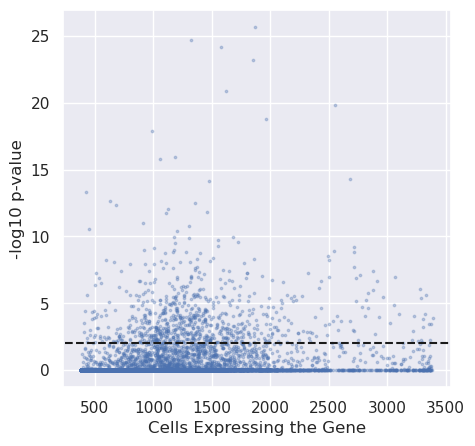

In [472]:
sns.set(rc={'figure.figsize':(5, 5)})

fig, ax = plt.subplots(1,1)

plt.scatter(x = CLONE_tests['n_cells'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('Cells Expressing the Gene')
save_figure(fig, 'pvalbyCellsExpressingGene')

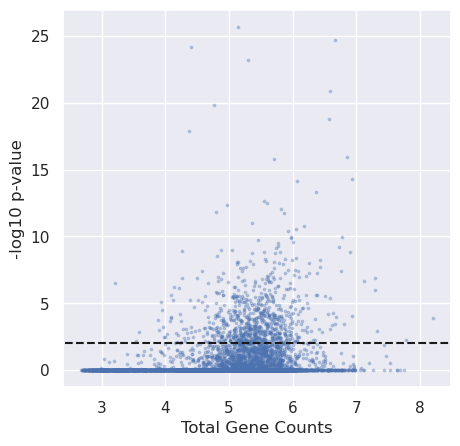

In [473]:
fig, ax = plt.subplots(1,1)
plt.scatter(x = np.log10(CLONE_tests['n_counts']), y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('Total Gene Counts')
save_figure(fig, 'pvalbyGeneCounts')

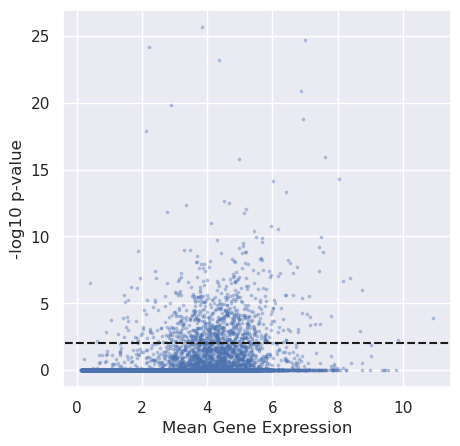

In [474]:
fig, ax = plt.subplots(1,1)
plt.scatter(x = CLONE_tests['means'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('Mean Gene Expression')
save_figure(fig, 'pvalbyMeanExpression')

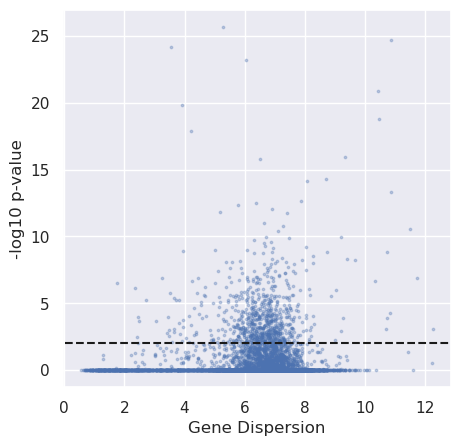

In [475]:
fig, ax = plt.subplots(1,1)
plt.scatter(x = CLONE_tests['dispersions'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('Gene Dispersion')
save_figure(fig, 'pvalbyDispersion')

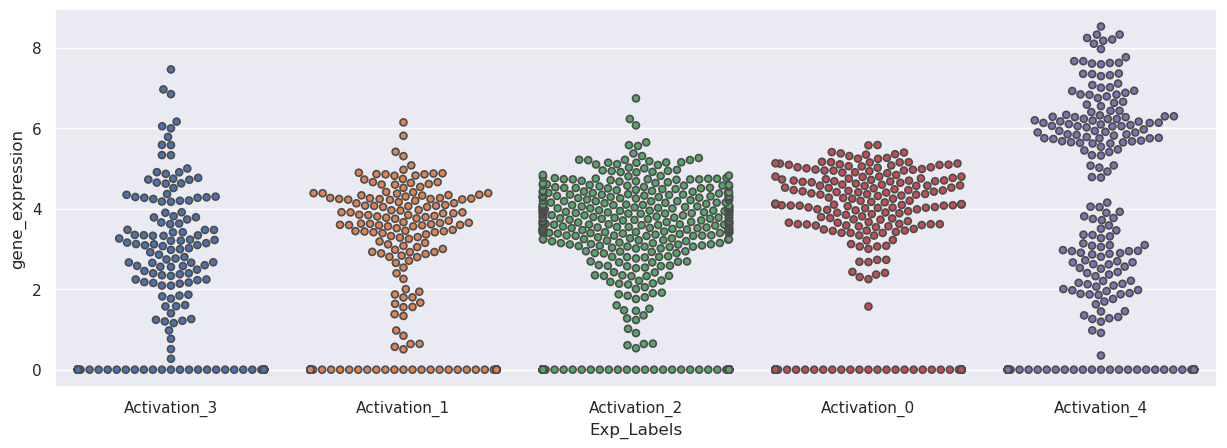

In [41]:
Activation = adata_obs[adata_obs.Exp_Labels.str.contains('Activation')]

sns.set(rc={'figure.figsize':(15, 5)})

new_df = pd.DataFrame([Activation['Exp_Labels'].to_list(), Activation[gene].to_list()])
data = new_df.T
data.columns = ['Exp_Labels', 'gene_expression']
data['gene_expression'] = data.gene_expression.astype('float')

order = data.groupby('Exp_Labels')['gene_expression'].mean().sort_values().index

sns.swarmplot(data = data, x = 'Exp_Labels', y = 'gene_expression',order = order, size = 5, linewidth = 1.2)

In [558]:
data1 = data[data.CLONE.isin((data.CLONE.value_counts() > 1).index)]

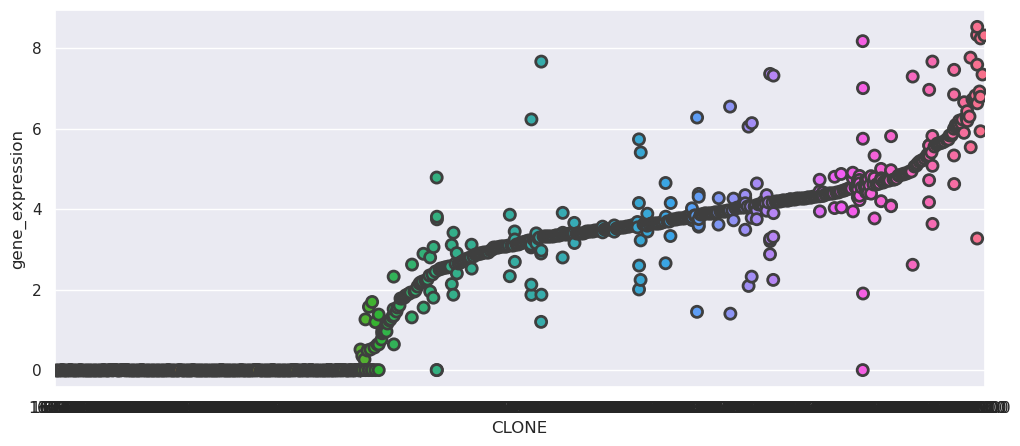

In [559]:
sns.set(rc={'figure.figsize':(12, 5)})

new_df = pd.DataFrame([labelstesting['CLONE'].to_list(), labelstesting[gene].to_list()])
data = new_df.T
data.columns = ['CLONE', 'gene_expression']
sns.stripplot(data = data1, x = 'CLONE', y = 'gene_expression', order = data1.groupby('CLONE')['gene_expression'].mean().sort_values().index, size = 8, linewidth = 2, palette = sns.husl_palette(n_colors=data.CLONE.nunique()))

In [132]:
divisiondf = compareGenesbyDivision(_df[genes], adata)

In [397]:
def addPearsonofGOIS(df, genelist, divisiondf):
    # Calculate correlation matrix
    df_corr = pd.DataFrame(np.corrcoef(df[genelist].values), columns=df.index, index = df.index)
    # Use LC to get Pearson for each comparison
    result = [df_corr.loc[x,y] for x, y in zip(divisiondf['cell1'], divisiondf['cell2'])]
    divisiondf['Pearson_GeneList'] = result
    return divisiondf

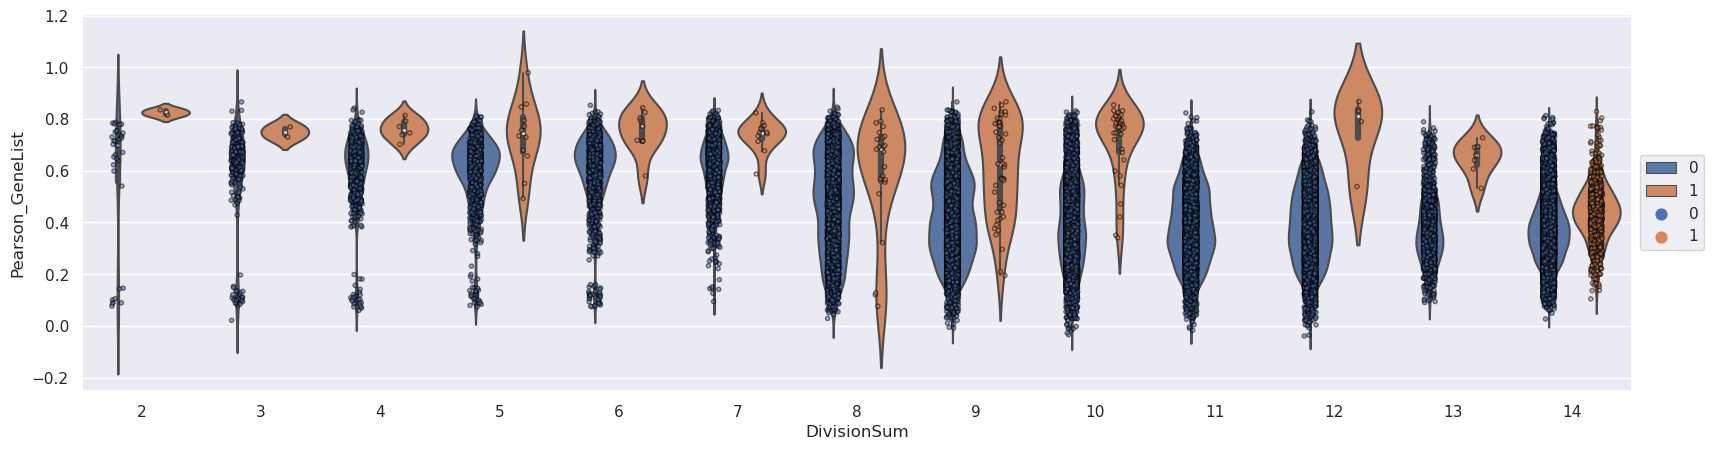

In [489]:
sns.set(rc={'figure.figsize':(20, 5)})

genelist = CLONE_tests.gene[CLONE_tests.corrected_pvalue < 0.001].values

divisiondf = addPearsonofGOIS(df, genelist, divisiondf_CLONE)


fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
#data = data[data['ClonalBool'] == 1]

params = dict(data = data, x = 'DivisionSum', y = 'Pearson_GeneList', hue = 'ClonalBool')
p_box = sns.violinplot(**params)
p = sns.stripplot(**params, alpha = 0.5, edgecolor = 'black', linewidth=1, size=3, dodge = True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


In [492]:
save_figure(fig, 'violinPearsonDivison')

In [493]:
divisiondf[divisiondf['DivisionSum'] == 2]

,cell1,cell2,Comparison,ClonalBool,DivisionSum,Pearson,NewPearson,Pearson_GeneList
2338,MS_REG_A7,MS_SISTER2_D14,MS_REG_A7*MS_SISTER2_D14,0,2,0.732718,0.732718,0.732718
2345,MS_REG_A7,MS_SISTER2_L19,MS_REG_A7*MS_SISTER2_L19,0,2,0.090426,0.090426,0.090426
2358,MS_REG_A7,MS_IL4_D4,MS_REG_A7*MS_IL4_D4,0,2,0.735271,0.735271,0.735271
2377,MS_REG_A7,MS_REG_E1,MS_REG_A7*MS_REG_E1,0,2,0.787401,0.787401,0.787401
2378,MS_REG_A7,MS_SISTER2_K1,MS_REG_A7*MS_SISTER2_K1,0,2,0.638851,0.638851,0.638851
2447,MS_REG_A7,MS_SISTER2_P13,MS_REG_A7*MS_SISTER2_P13,0,2,0.670931,0.670931,0.670931
2460,MS_REG_A7,MS_SISTER2_M11,MS_REG_A7*MS_SISTER2_M11,0,2,0.714247,0.714247,0.714247
2603,MS_REG_A7,D2_5_10_SplitSort_Dilution_Combined_P19,MS_REG_A7*D2_5_10_SplitSort_Dilution_Combined_P19,0,2,0.715443,0.715443,0.715443
4941,MS_SISTER2_D14,MS_SISTER2_L19,MS_SISTER2_D14*MS_SISTER2_L19,0,2,0.145874,0.145874,0.145874
4954,MS_SISTER2_D14,MS_IL4_D4,MS_SISTER2_D14*MS_IL4_D4,0,2,0.730455,0.730455,0.730455


In [420]:
adata = sc.read_h5ad('../data/CombinedDivision.h5ad')

In [424]:
adata.obs[adata.obs.DivisionNumber == '1'].CLONE.value_counts()

1470.0    2
616.0     2
2095.0    1
1183.0    1
397.0     1
         ..
1641.0    0
1639.0    0
1638.0    0
1636.0    0
111.0     0
Name: CLONE, Length: 1170, dtype: int64

In [421]:
adata.obs[adata.obs.Sort.str.contains('1st')].DivisionNumber.value_counts()

1              400
0              137
3               66
None             0
No Tracking      0
Max              0
6                0
5                0
4                0
2                0
Name: DivisionNumber, dtype: int64

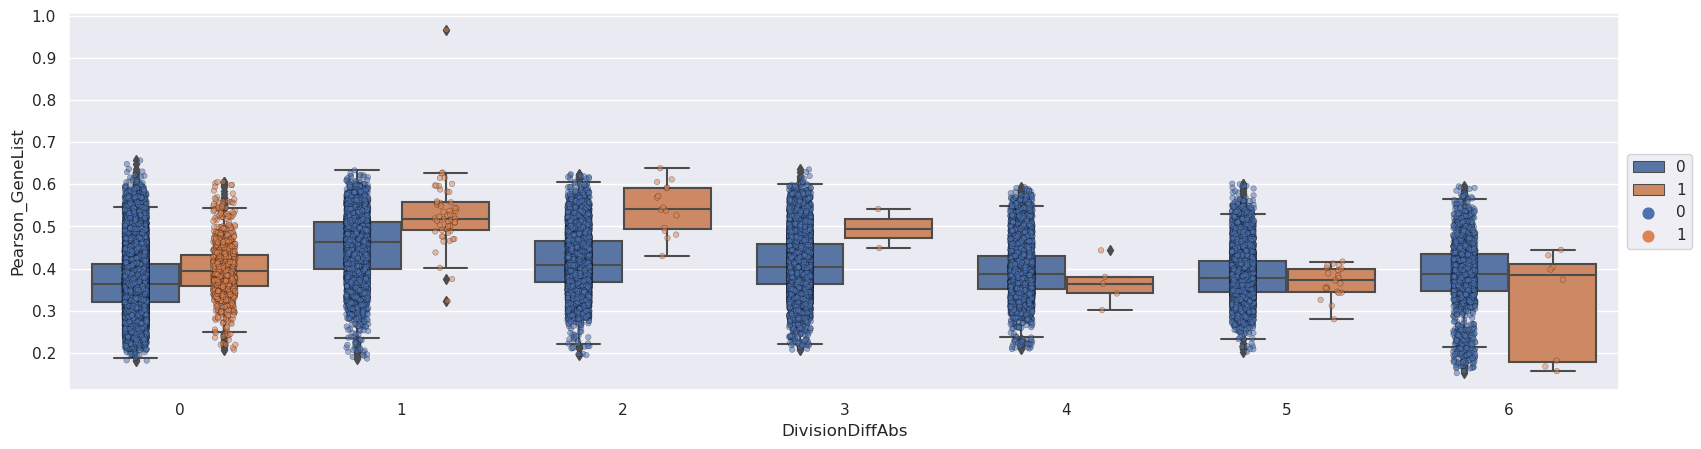

In [642]:
genelist = CLONE_tests.gene[CLONE_tests.corrected_pvalue > 0.7].values

divisiondf = addPearsonofGOIS(df, genelist, divisiondf_CLONE)
divisiondf['DivisionDiffAbs'] = np.abs(divisiondf['DivisionDiff'])
sns.set(rc={'figure.figsize':(20, 5)})


fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
#data = data[data['ClonalBool'] == 1]


params = dict(data = data, x = 'DivisionDiffAbs', y = 'Pearson_GeneList', hue = 'ClonalBool')
p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.5, edgecolor = 'black', linewidth=0.3, size=4, dodge = True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [496]:
save_figure(fig, "violinPearsonNonClonal")

In [503]:
divisiondf_CLONE.cell2.nunique()

336

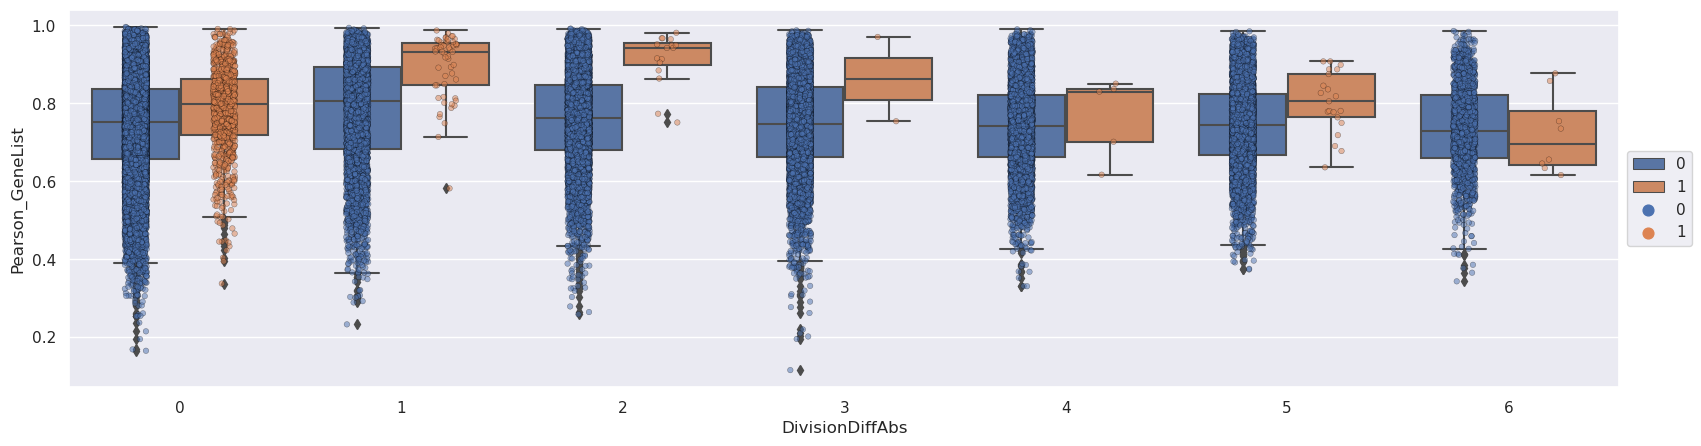

In [643]:
genelist = CLONE_tests.gene[(CLONE_tests.corrected_pvalue < 0.01) & (CLONE_tests.gene.str.contains('MT'))].values

genelist = genelist[1:-1]
divisiondf = addPearsonofGOIS(df, genelist, divisiondf_CLONE)

sns.set(rc={'figure.figsize':(20, 5)})


fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]

params = dict(data = data, x = 'DivisionDiffAbs', y = 'Pearson_GeneList', hue = 'ClonalBool')
p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.5, edgecolor = 'black', linewidth=0.3, size=4, dodge = True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [533]:
save_figure(fig, "boxPearsonMT")

In [513]:
CLONE_tests[CLONE_tests.gene.isin(['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHA1', 'IGHE', 'IGHA2'])]

CLONE_tests.gene[:9].values

3268      HLA-DQB2
9529         IGLC3
1343      HMGN1P36
3267      HLA-DQA2
9528         IGLC2
791     AL365357.1
1318          IGKC
9843    AC004556.1
7783         CCL17
Name: gene, dtype: object

In [528]:
CLONE_tests.gene[CLONE_tests.corrected_pvalue > 0.7].values[-9:]

array(['DNAAF5', 'COX19', 'ZFAND2A', 'INTS1', 'PSMG3', 'MAD1L1', 'MRM2',
       'SUN1', 'AC240274.1'], dtype=object)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/numpy/lib/function_base.py:2534: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/numpy/lib/function_base.py:2535: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


['ELOB' 'GLMN' 'ASXL1' 'CWF19L1' 'PYCR2' 'CCDC85B' 'CARS' 'MSN' 'MT-ND5'
 'FRYL' 'EIF3K' 'C7orf49']


Text(0, 0.5, 'Pearson Correlation')

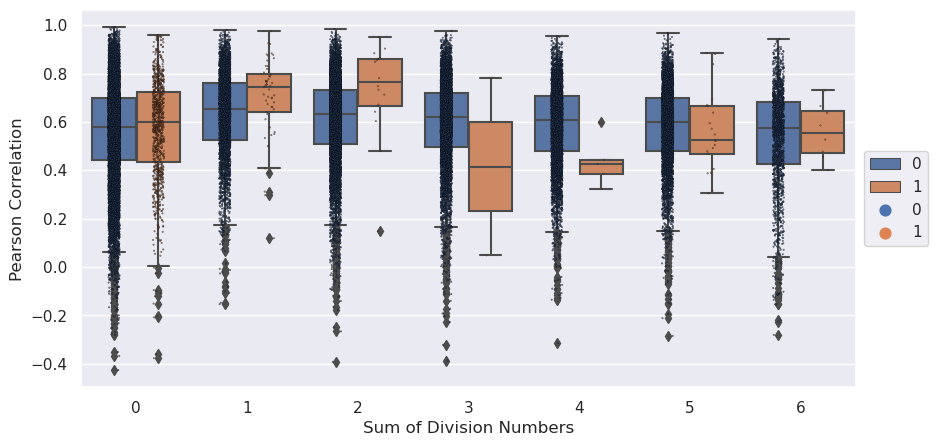

In [648]:
# IgH
genelist = ['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG4', 'IGHE']
# best
genelist = CLONE_tests.gene[:12].values
# worst
genelist = CLONE_tests.gene[CLONE_tests.corrected_pvalue > 0.7].values[:12]

# Mito
#genelist = CLONE_tests.gene[(CLONE_tests.corrected_pvalue < 0.01) & (CLONE_tests.gene.str.contains('MT'))].values
#genelist = genelist[1:-1]

divisiondf = addPearsonofGOIS(df, genelist, divisiondf_CLONE)

sns.set(rc={'figure.figsize':(10, 5)})

print(genelist)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
params = dict(data = data, x = 'DivisionDiffAbs', y = 'Pearson_GeneList', hue = 'ClonalBool')
p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.6, edgecolor = 'black', linewidth=0.4, size=1, dodge = True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Pearson Correlation')

In [649]:
save_figure(fig, "DivisionDiffBoxPlot_WorstGenes")

['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHA1', 'IGHE', 'IGHA2']


Text(0.5, 1.0, 'IGH Locus')

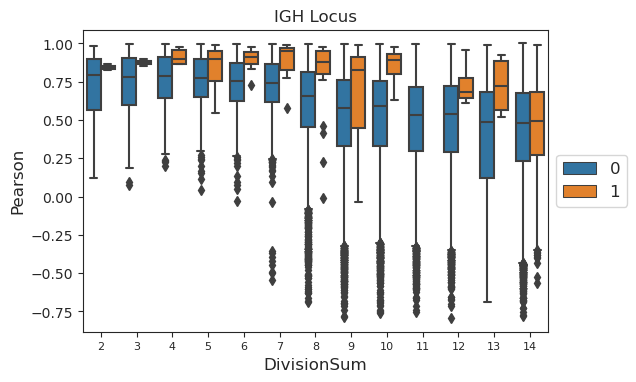

In [135]:
print(genes)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
sns.boxplot(data=data, x = 'DivisionSum', y = 'Pearson', hue = 'Clonal?')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('IGH Locus')

['LGALS1' 'ENSG00000277048' 'IGKC' 'IGHE' 'FTL' 'IGHG2' 'ITGA4' 'IGLC2'
 'ANXA6' 'ACTBP2' 'IGLC3' 'JCHAIN' 'GATM' 'CCL17' 'IGHG3' 'ORAI3' 'ZNF766'
 'SLA' 'TNFAIP2' 'AC018926.2' 'COMT' 'AFF3' 'ALPL' 'ITGAX' 'IGHM' 'SRGN'
 'POTEF' 'HSPA5' 'SLC1A4' 'CCL5']


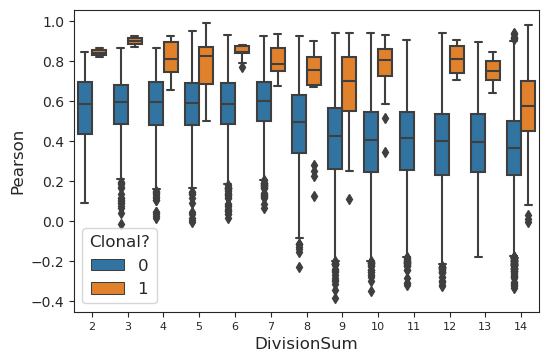

In [112]:
print(genes)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
sns.boxplot(data=data, x = 'DivisionSum', y = 'Pearson', hue = 'Clonal?')

In [590]:
import switchy.util as ut

,WASH7P,AL627309.6,AL627309.5,FO538757.1,AP006222.1,AL732372.2,MTND1P23,MTND2P28,ENSG00000276171,MTCO1P12,...,ENSG00000274482,ENSG00000276736,AL354822.1,AC004556.1,AC233755.2,AC233755.1,AC240274.1,RF00003-14,Cytomegalovirus,T7
CTY_I8,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.323401,3.465954,0.000000,4.410459,...,0.0,0.000000,0.0,2.645596,3.043678,0.000000,0.000000,0.000000,0.0,0.0
MS_SISTER2_J10,1.404345,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,3.067388,0.705217,4.867996,...,0.0,0.000000,0.0,2.730464,0.000000,0.705217,0.705217,0.000000,0.0,0.0
MS_IL4_F1,0.000000,0.000000,0.000000,2.028493,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,3.035331,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
CTY_H21,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,4.665248,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
MS_IL4_L6,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.296115,0.000000,4.684222,...,0.0,0.000000,0.0,3.073637,0.000000,0.000000,0.000000,0.864868,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IL6811_716_503,0.000000,0.000000,4.005235,0.000000,0.0,1.883165,0.000000,4.944190,0.000000,1.883165,...,0.0,1.883165,0.0,5.297397,0.000000,0.000000,0.000000,0.000000,0.0,0.0
IL6811_710_505,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,3.457329,0.000000,4.418265,...,0.0,0.000000,0.0,0.000000,0.000000,5.018906,0.000000,0.000000,0.0,0.0
IL6811_706_520,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,4.972528,0.000000,4.625749,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
IL6811_722_517,1.771915,3.021811,0.000000,0.000000,0.0,0.000000,0.000000,4.307190,0.000000,4.685887,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.235778,0.000000,0.0,0.0


In [617]:
clone = adata.obs.CLONE.value_counts().index[10]

In [618]:
data = df[genelist]
celllist = adata.obs.index[adata.obs.CLONE == clone ]

No handles with labels found to put in legend.
No handles with labels found to put in legend.


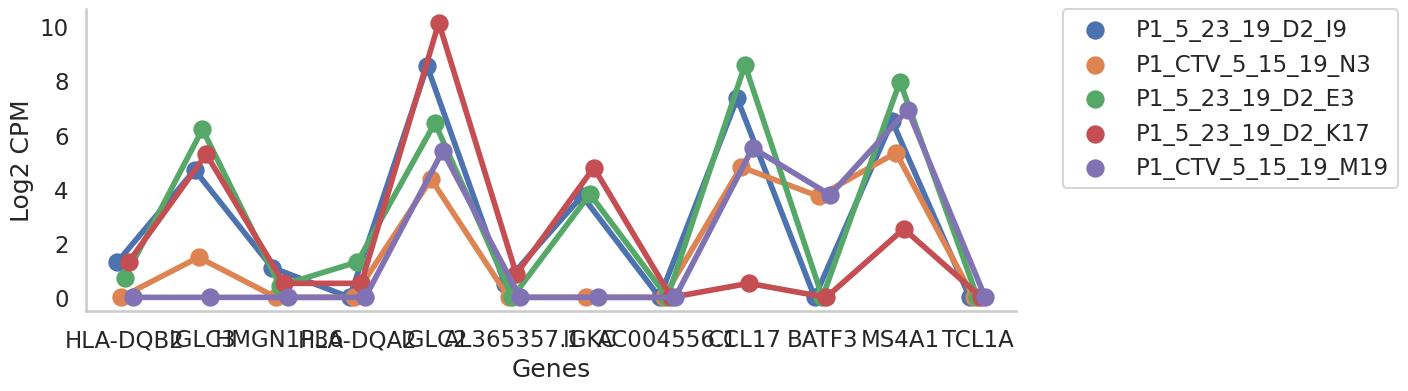

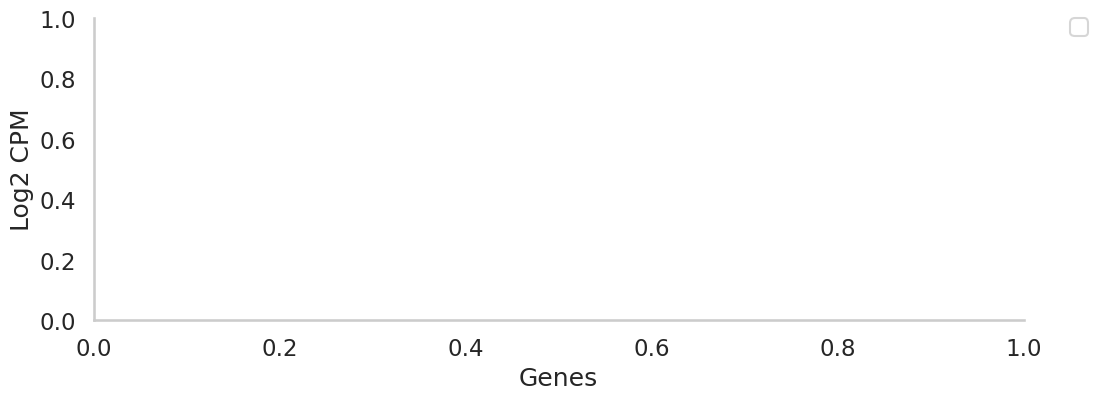

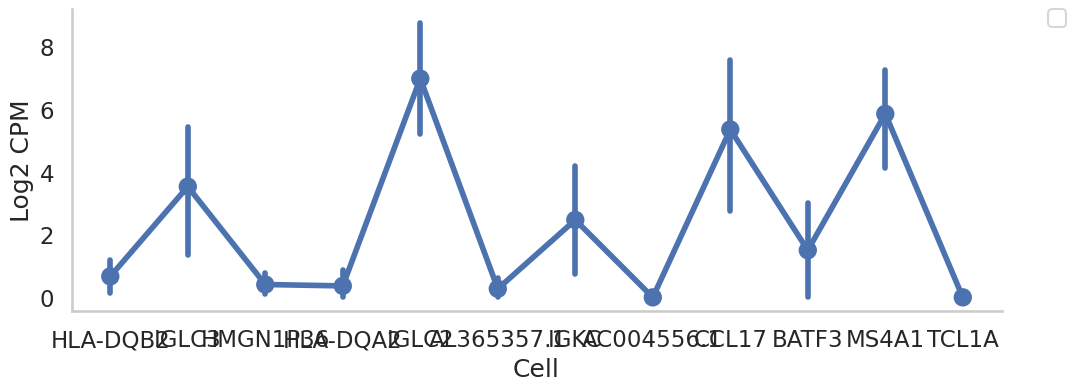

In [619]:
ut.plotPointPlotLocus(data, celllist
                    )

In [ ]:
## Find bi-modal clonal genes 

# Load up list of clonal genes 

# Count number of zeroes for that gene amongst the clones in the dataset

# if that number is more than 20% plot those 

# quantify how many of those types of genes there are 


In [12]:
# Load the Tests
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Exp_Labels_tests.csv', index_col = 0)

In [16]:
CLONE_tests.n_cells.value_counts().index.sort_values()

Int64Index([ 380,  381,  382,  383,  384,  385,  386,  387,  388,  389,
            ...
            3367, 3368, 3369, 3370, 3371, 3375, 3377, 3379, 3384, 3393],
           dtype='int64', length=2062)

In [46]:
significant_genes = CLONE_tests[CLONE_tests.corrected_pvalue < 0.01].gene

In [ ]:
_

In [79]:
_adataobs[gene] = _df[gene]

In [78]:
gene = 'IGKC'

In [98]:
((_adataobs.groupby('CLONE')[gene].mean() <= 0.1).value_counts().to_frame().loc[False] < 87).values[0]

False

In [116]:
bimodals_sweep = []
num_clones_no_zero = []
for i in range(90):
    bimodals = []
    for gene in significant_genes:
        #_adataobs.groupby('CLONE')[gene].mean()
        #selector = (_df[_df[gene] <= 0.1]).index
        #num_zeroes = _df[_df.index.isin(selector)].shape[0]
        _adataobs[gene] = _df[gene]
        if ((_adataobs.groupby('CLONE')[gene].mean() <= 0.1).value_counts().to_frame().loc[False] < i).values[0] == True:
            bimodals.append(gene)
    bimodals_sweep.append(len(bimodals))
    num_clones_no_zero.append(i)

In [133]:
bimodals_sweep = []
num_clones_no_zero = []
for i in range(103):
    bimodals = []
    for gene in significant_genes:
        #_adataobs.groupby('CLONE')[gene].mean()
        #selector = (_df[_df[gene] <= 0.1]).index
        #num_zeroes = _df[_df.index.isin(selector)].shape[0]
        _adataobs[gene] = _df[gene]
        if ((_adataobs.groupby('CLONE')[gene].mean() <= 0.1).value_counts().to_frame().loc[False] < i).values[0] == True:
            bimodals.append(gene)
    bimodals_sweep.append(len(bimodals))
    num_clones_no_zero.append(i)

Text(0, 0.5, 'Number of Bimodal Genes')

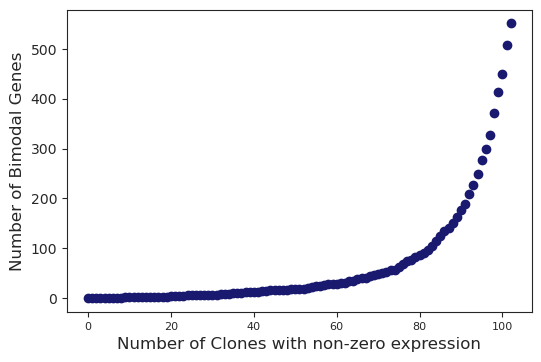

In [135]:
fig, ax = plt.subplots(1,1)

plt.plot(num_clones_no_zero, bimodals_sweep, 'bo', c = 'midnightblue')
plt.xlabel('Number of Clones with non-zero expression')
plt.ylabel('Number of Bimodal Genes')

In [132]:
bimodals65 = bimodals

In [126]:
CLONE_tests[CLONE_tests.gene.str.contains('IGKV|IGHV|IGLV')]

,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,gene,pvalue,corrected_pvalue
1320,421,2295830.0,True,6.407549,10.855769,3.613952,0.0,IGKV3-20,4.833767e-18,4.758843e-14
7176,450,1142658.0,True,6.163892,11.491192,4.295528,0.0,IGHV3-30,3.000851e-15,2.954338e-11


['IGLC3',
 'IGLC2',
 'IGKV3-20',
 'PRDM1',
 'CPNE5',
 'IGHV3-30',
 'IGHE',
 'CD38',
 'FAM46C',
 'PSPHP1',
 'CAVIN3',
 'MIR3945HG',
 'ACTG1P19',
 'SGK1',
 'SF3A2',
 'MIR8071-1',
 'MT2A',
 'ZBP1',
 'CEP128',
 'CKAP4',
 'FAM30A',
 'ALOX5',
 'IGHEP1',
 'CADM1',
 'TP53INP1',
 'MIAT',
 'XYLT2',
 'PDE4D',
 'CFI',
 'ARID3A',
 'ERN1',
 'SHISA3',
 'STX5',
 'LMO2',
 'CKB',
 'TRAM2',
 'IL6',
 'COL9A2',
 'IL13RA1',
 'CCDC152',
 'ANKRD36BP2',
 'LSR',
 'CLEC2B',
 'IGHGP',
 'SLC7A5',
 'SPATA20',
 'BTG2',
 'VSIR']

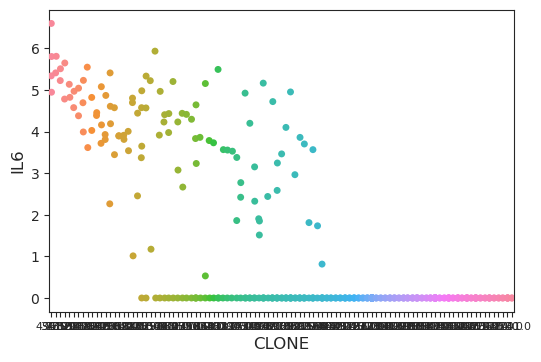

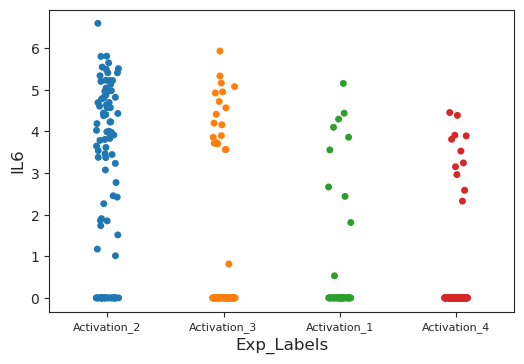

In [106]:
gene = 'IL6'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

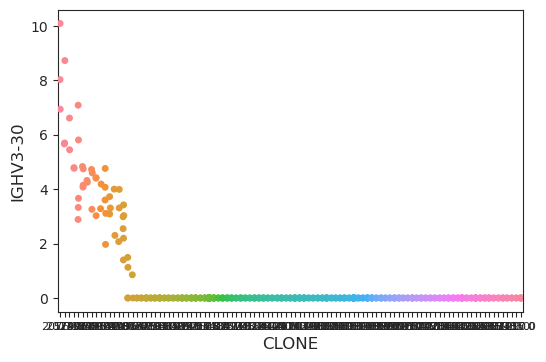

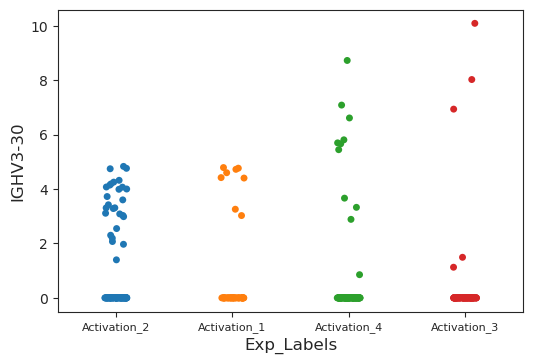

In [115]:
gene = 'IGHV3-30'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

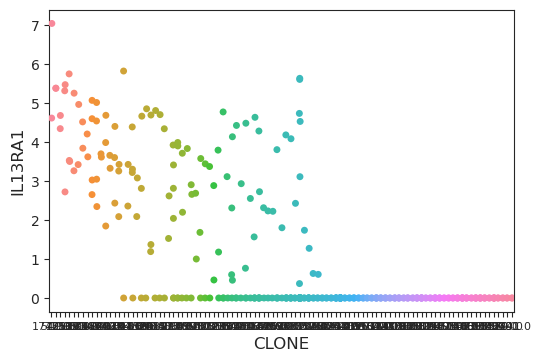

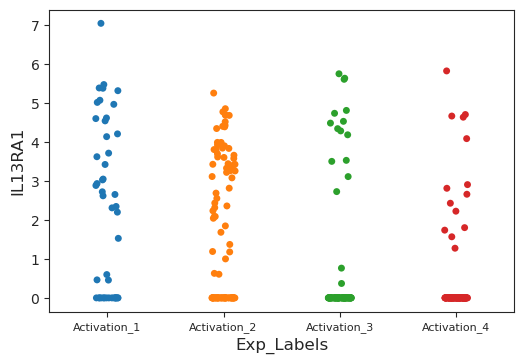

In [107]:
gene = 'IL13RA1'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

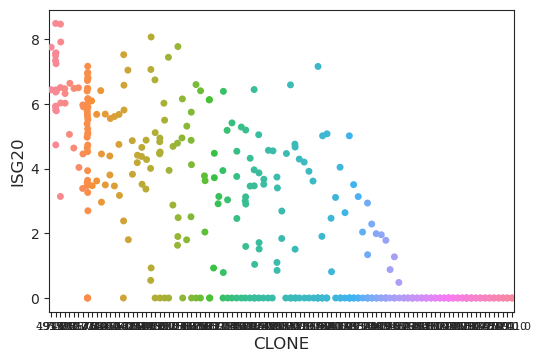

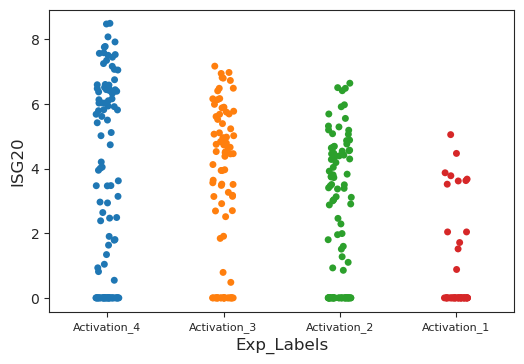

In [108]:
gene = 'ISG20'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

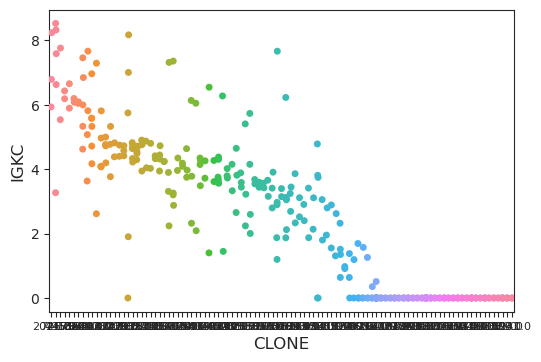

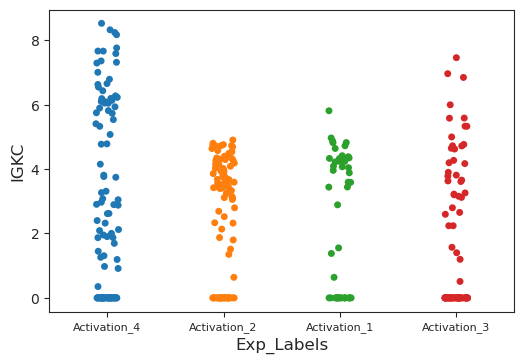

In [109]:
gene = 'IGKC'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

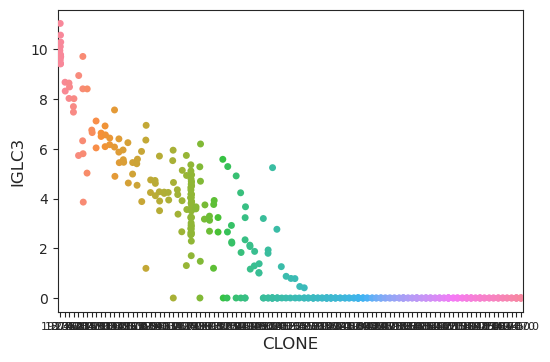

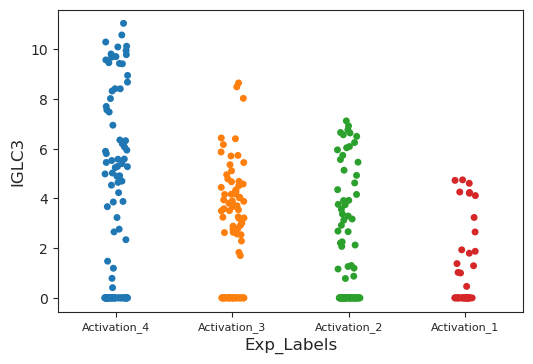

In [110]:
gene = 'IGLC3'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

In [63]:
_adataobs = _adata.obs

In [61]:
_df['IGKC']

CTY_L1                                     0.000000
CTY_J10                                    2.888874
CTY_P23                                    0.000000
MS_IL4_O3                                  4.150664
CTY_B15                                    0.000000
                                             ...   
P1_5_23_19_D2_O11                          0.000000
P1_5_23_19_D2_A19                          6.099801
P1_5_23_19_D2_M5                           8.524038
P1_CTV_5_15_19_M19                         0.000000
D2_5_10_SplitSort_Dilution_Combined_M10    0.000000
Name: IGKC, Length: 337, dtype: float32

In [60]:
gene = 'IGKC'

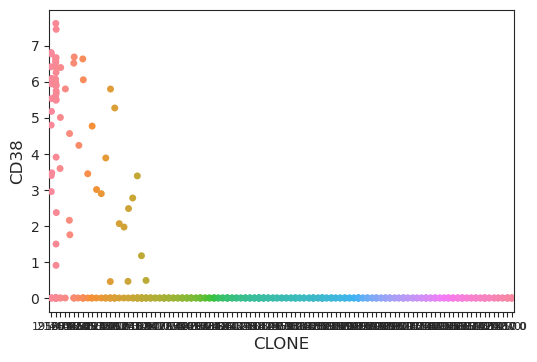

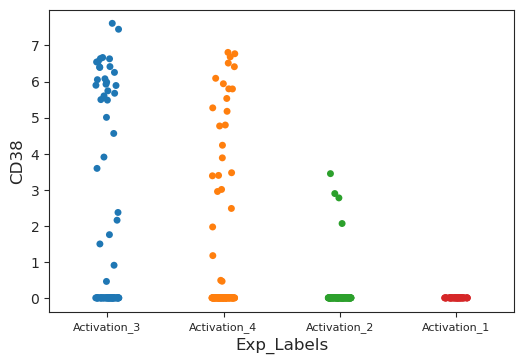

In [138]:
gene = 'CD38'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

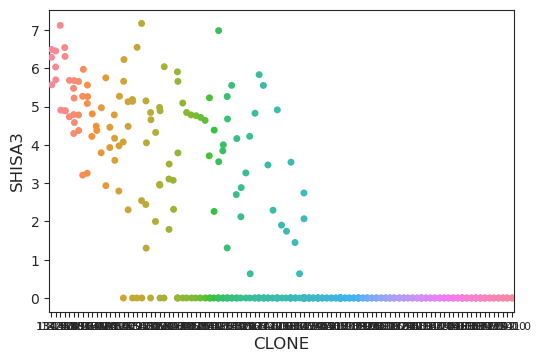

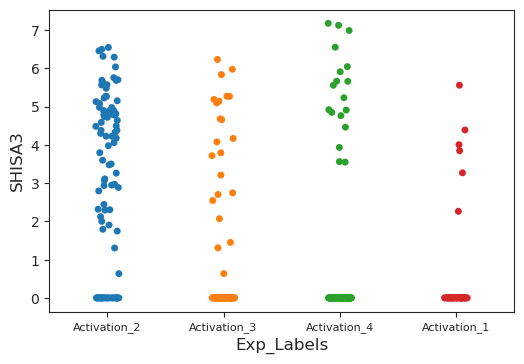

In [139]:
gene = 'SHISA3'
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'CLONE', False)
fig, labelstesting = cs.plotWaterfall(_df, _adataobs, gene, 'Exp_Labels', False)

In [136]:
bimodals65

['IGLC3',
 'IGLC2',
 'IGKV3-20',
 'PRDM1',
 'CPNE5',
 'IGHV3-30',
 'IGHE',
 'CD38',
 'FAM46C',
 'PSPHP1',
 'CAVIN3',
 'ACTG1P19',
 'MIR8071-1',
 'MT2A',
 'ZBP1',
 'CEP128',
 'CKAP4',
 'FAM30A',
 'IGHEP1',
 'CADM1',
 'MIAT',
 'XYLT2',
 'PDE4D',
 'ERN1',
 'SHISA3',
 'CKB',
 'TRAM2',
 'IL6',
 'COL9A2',
 'IL13RA1',
 'CCDC152',
 'ANKRD36BP2',
 'CLEC2B',
 'IGHGP',
 'SLC7A5',
 'SPATA20',
 'BTG2',
 'VSIR']